# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

from imblearn.over_sampling import SMOTE

import joblib

np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


# Load the One-Hot Encoded Dataset

In [2]:
BASE_DIR = Path.cwd().parent

file_path = BASE_DIR / "Day 2" / "features_v1.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_Male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1.0,0,A/5 21171,7.2500,Unknown,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1.0,0,PC 17599,65.6344,C85,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0.0,0,STON/O2. 3101282,7.9250,Unknown,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1.0,0,113803,53.1000,C123,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0.0,0,373450,8.0500,Unknown,True,False,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    float64
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    str    
 8   Fare         891 non-null    float64
 9   Cabin        891 non-null    str    
 10  Sex_Male     891 non-null    bool   
 11  Embarked_Q   891 non-null    bool   
 12  Embarked_S   891 non-null    bool   
dtypes: bool(3), float64(3), int64(4), str(3)
memory usage: 72.3 KB


In [5]:
print(df.shape)

(891, 13)


In [6]:
X = df[
    [
        "Pclass",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Sex_Male",
        "Embarked_Q",
        "Embarked_S"
    ]
]

y = df["Survived"]

print("Features and target selected successfully!")

Features and target selected successfully!


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train-Test split completed!")

Train-Test split completed!


In [8]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (712, 8)
X_test : (179, 8)
y_train: (712,)
y_test : (179,)


# Class Distribution Analysis

Before applying SMOTE, it is important to analyze the distribution of the target variable.

Class imbalance occurs when one class has significantly more samples than the other. A highly imbalanced dataset can cause a Machine Learning model to favor the majority class and perform poorly on the minority class.

In [9]:
print("Training Set Class Distribution:")
print(y_train.value_counts())

Training Set Class Distribution:
Survived
0    444
1    268
Name: count, dtype: int64


In [10]:
print("Training Set Class Distribution (%):")
print(y_train.value_counts(normalize=True) * 100)

Training Set Class Distribution (%):
Survived
0    62.359551
1    37.640449
Name: proportion, dtype: float64


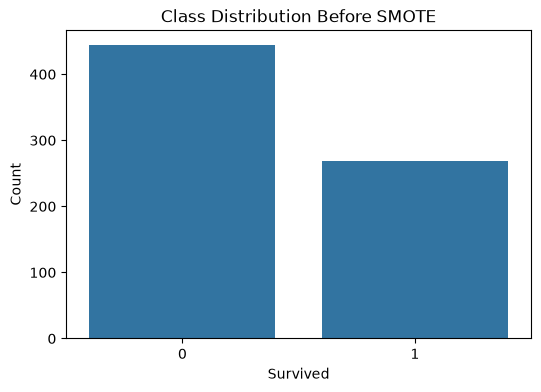

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Class Distribution Before SMOTE")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

## Observation

The class distribution shows whether the dataset is balanced or imbalanced.

If one class contains significantly more samples than the other, the model may become biased toward predicting the majority class. This often results in poor performance on the minority class, even if the overall accuracy appears high.

To address this issue, SMOTE will be applied only to the training dataset in the next step.

# Applying SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) is used to balance the training dataset by generating synthetic samples for the minority class.

To prevent data leakage, SMOTE is applied **only** to the training data after the Train-Test split.

In [14]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("SMOTE applied successfully!")

SMOTE applied successfully!


In [15]:
print("Class Distribution After SMOTE:")
print(y_train_smote.value_counts())

Class Distribution After SMOTE:
Survived
0    444
1    444
Name: count, dtype: int64


In [16]:
print("Class Distribution After SMOTE (%):")
print(y_train_smote.value_counts(normalize=True) * 100)

Class Distribution After SMOTE (%):
Survived
0    50.0
1    50.0
Name: proportion, dtype: float64


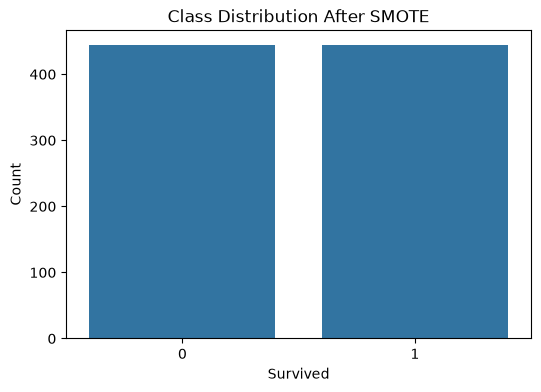

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_smote)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

## Observation

After applying SMOTE, the minority class was increased by generating synthetic training samples until both classes contained the same number of observations.

This balanced dataset allows the Random Forest model to learn patterns from both classes more effectively without altering the testing dataset.

# Random Forest Model Training

After balancing the training dataset using SMOTE, we train a Random Forest Classifier.

The model is trained **only** on the balanced training dataset and later evaluated using the untouched testing dataset.

In [19]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model initialized successfully!")

Random Forest model initialized successfully!


In [20]:
# Train on the SMOTE-balanced training data
rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [21]:
# Predict on the original testing dataset
y_pred = rf_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [22]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,1,1
4,1,0
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


## Observation

The Random Forest model was trained using the SMOTE-balanced training dataset. Predictions were generated using the original testing dataset, ensuring that no synthetic samples were used during evaluation.

This follows good Machine Learning practices and prevents data leakage.|

# Model Evaluation

The Random Forest model is evaluated using the original testing dataset. The F1-score is used because it provides a balanced measure of precision and recall, making it useful for classification problems with class imbalance.

In [23]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



In [24]:
post_smote_f1 = f1_score(y_test, y_pred)

print(f"Post-SMOTE F1 Score: {post_smote_f1:.4f}")

Post-SMOTE F1 Score: 0.7973


In [25]:
# Train Random Forest without SMOTE
baseline_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

baseline_rf.fit(X_train, y_train)

baseline_pred = baseline_rf.predict(X_test)

pre_smote_f1 = f1_score(y_test, baseline_pred)

print(f"Pre-SMOTE F1 Score : {pre_smote_f1:.4f}")
print(f"Post-SMOTE F1 Score: {post_smote_f1:.4f}")

Pre-SMOTE F1 Score : 0.7972
Post-SMOTE F1 Score: 0.7973


In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Age,0.299292
4,Fare,0.293349
5,Sex_Male,0.212957
0,Pclass,0.093366
2,SibSp,0.066973
7,Embarked_S,0.018810
6,Embarked_Q,0.015254
3,Parch,0.000000


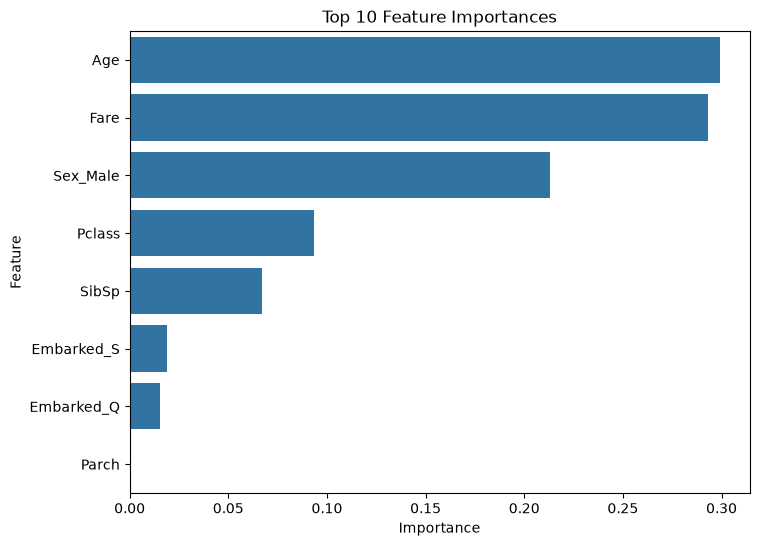

In [27]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Business Interpretation

The Feature Importance chart shows which variables have the greatest influence on the model's predictions.

Features with higher importance contribute more to determining whether a passenger survived. Understanding these influential variables helps explain the model's decision-making process and improves transparency for business stakeholders.

Rather than treating the model as a "black box," Feature Importance provides insight into which factors are most valuable for prediction.

# Export the Trained Model

In [28]:
# Save the trained Random Forest model
joblib.dump(rf_model, "production_rf_model.pkl")

print("Model exported successfully!")

Model exported successfully!


# Conclusion

In this project:

- Class imbalance was identified using the training dataset.
- SMOTE was applied only to the training data.
- A Random Forest model was trained using the balanced dataset.
- Model performance was evaluated on the untouched testing dataset.
- Feature importance was extracted and visualized.
- The F1-score before and after SMOTE was compared.

These steps improve both model fairness and interpretability while preventing data leakage.